In [118]:

# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data 

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)
# fitler for the job titles and country



In [119]:
df_US = df[df['job_country'] == 'United States'].dropna(subset=['salary_year_avg'])

In [120]:
job_titles = df_US['job_title_short'].value_counts().index[:6].tolist()

job_titles

['Data Scientist',
 'Data Analyst',
 'Data Engineer',
 'Senior Data Scientist',
 'Senior Data Engineer',
 'Senior Data Analyst']

In [121]:
df_US_top6 = df_US[df_US['job_title_short'].isin(job_titles)]

In [122]:
job_order = df_US_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

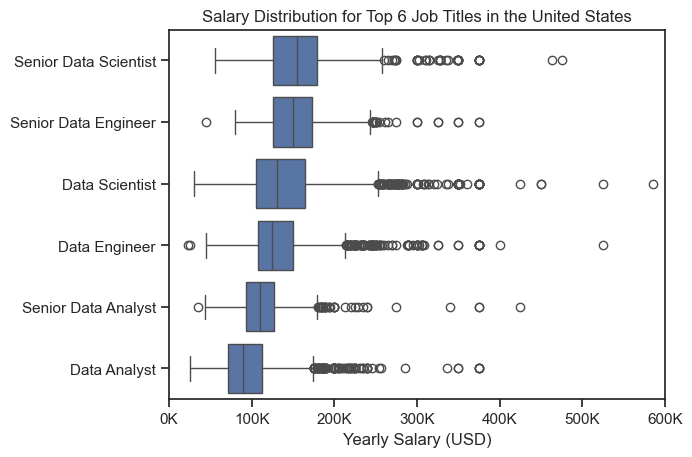

In [123]:
sns.boxplot(data=df_US_top6, x='salary_year_avg', y='job_title_short', order=job_order)
sns.set_theme(style="ticks")
plt.title('Salary Distribution for Top 6 Job Titles in the United States')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 600000)
ticks_x = plt.FuncFormatter(lambda x, pos: f'{int(x/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()

In [124]:
df_da_us = df[
    (df['job_title_short'] == 'Data Analyst') &
    (df['job_country'] == 'United States')
].copy()


df_da_us = df_da_us.dropna(subset=['salary_year_avg'])

In [127]:
# explode once
df_da_us = df_da_us.explode('job_skills').dropna(subset=['job_skills'])

df_da_top_pay = (
    df_da_us.groupby('job_skills')['salary_year_avg']
    .agg(count='size', median='median')
    .sort_values('median', ascending=False)
    .head(10)
)

df_da_skill_demand = (
    df_da_us.groupby('job_skills')['salary_year_avg']
    .agg(count='size', median='median')
    .sort_values('count', ascending=False)
    .head(10)
)

/var/folders/91/tlk_wcw57997qcnvdgbvwfq80000gn/T/ipykernel_10965/458055637.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/91/tlk_wcw57997qcnvdgbvwfq80000gn/T/ipykernel_10965/458055637.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


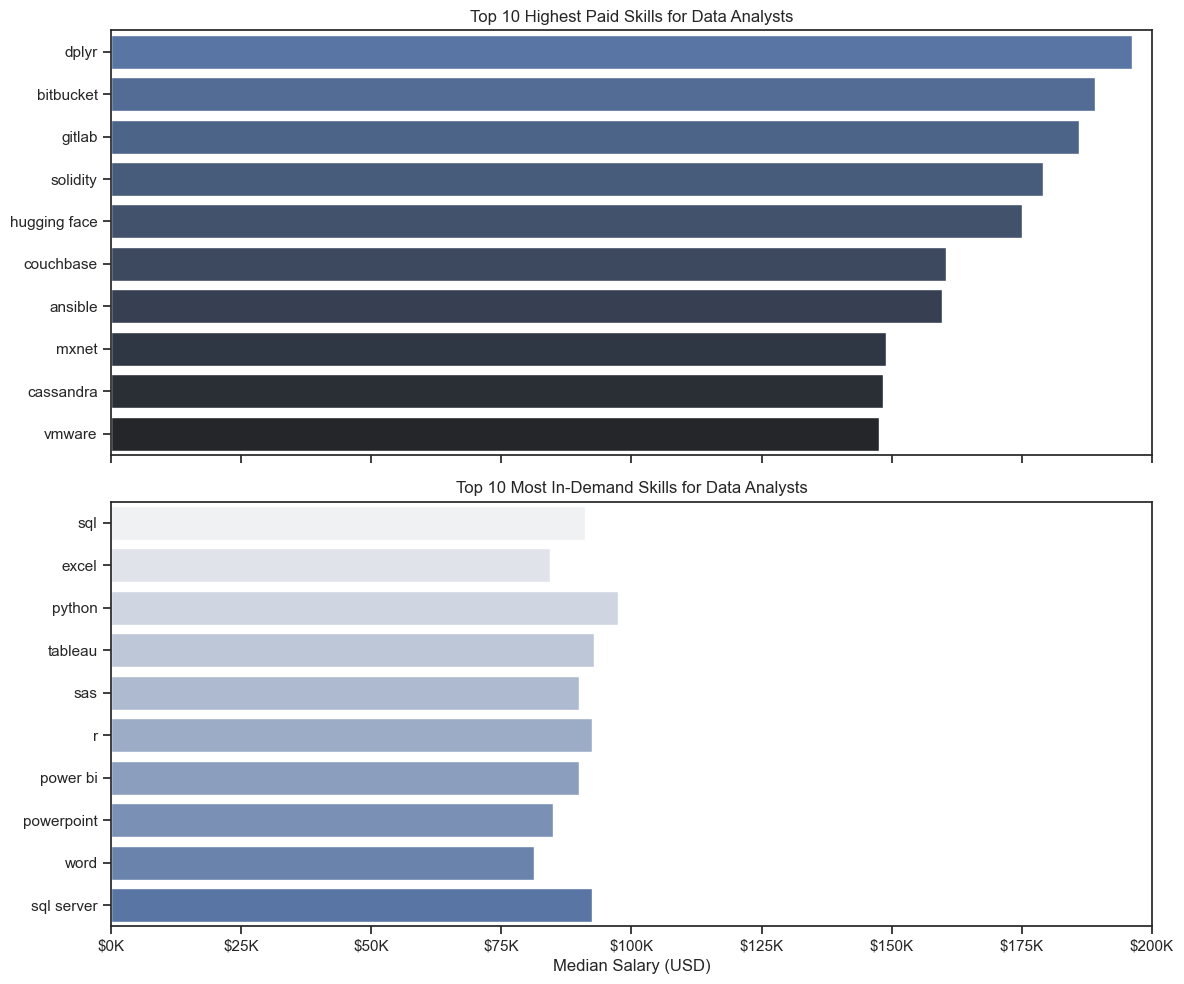

In [134]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
sns.set_theme(style='ticks')

df_top_pay = df_da_top_pay.reset_index()
sns.barplot(
    data=df_top_pay,
    x='median',
    y='job_skills',
    ax=axes[0],
    palette='dark:b_r'
)
axes[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
axes[0].set_ylabel('')
axes[0].set_xlabel('')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K')
)
axes[0].set_xlim(0, 200000)
if axes[0].get_legend():
    axes[0].get_legend().remove()

df_skill_demand = df_da_skill_demand.reset_index().sort_values('count', ascending=False).head(10)
sns.barplot(
    data=df_skill_demand,
    x='median',
    y='job_skills',
    ax=axes[1],
    palette='light:b'
)
axes[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
axes[1].set_ylabel('')
axes[1].set_xlabel('Median Salary (USD)')
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K')
)
axes[1].set_xlim(0, 200000)
if axes[1].get_legend():
    axes[1].get_legend().remove()

plt.tight_layout()
plt.show()